# Домашнее задание #4: исследование линейной регрессии

## 1. Краткое описание датасета
`ToyotaCorolla.csv`

Наша целевая переменная — цена автомобиля (`Price`).

В качестве признаков выступают различные характеристики: возраст (`Age_08_04`), пробег (`KM`), мощность двигателя (`HP`), тип топлива (`Fuel_Type`), наличие различных опций (кондиционер, ABS и т.д.).

В данных есть как числовые, так и категориальные переменные.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('ToyotaCorolla.csv')
display(df.head())

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


Размерность данных: (1436, 39)
<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64

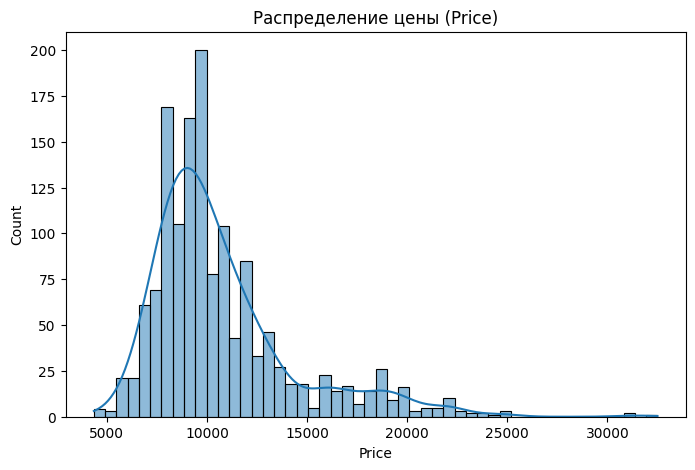

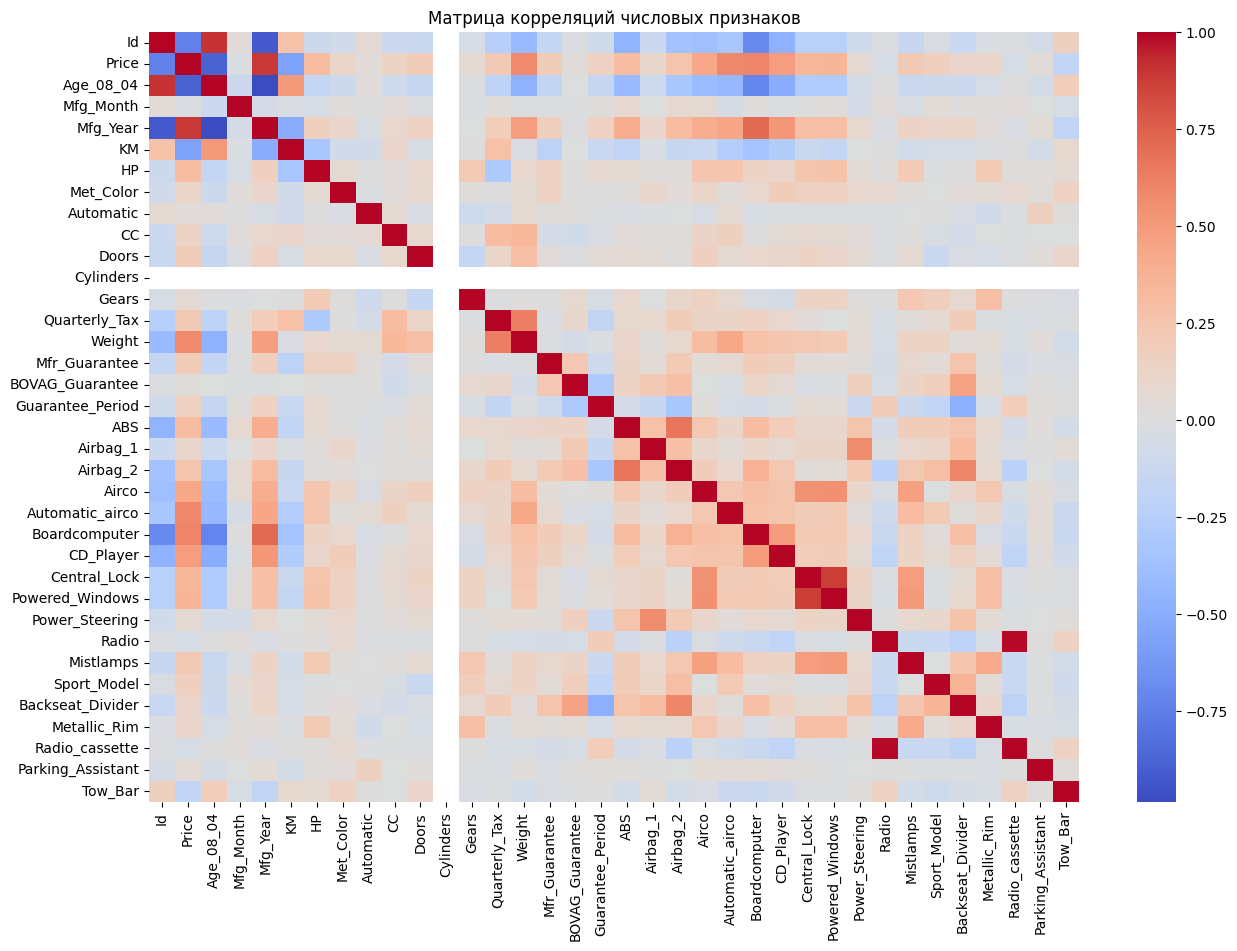

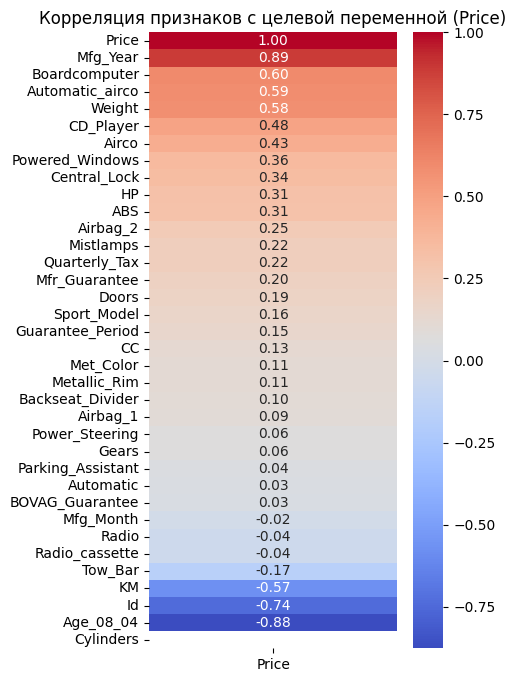

In [82]:
# Базовая информация
print("Размерность данных:", df.shape)
df.info()

print("\nПроверка на наличие пропусков:")
print(df.isnull().sum().max()) # Убедимся, что пропусков нет

# Распределение целевой переменной
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Распределение цены (Price)')
plt.show()

# Корреляционная матрица числовых признаков
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 10))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций числовых признаков')

# Отдельно выведем корреляцию всех признаков ТОЛЬКО с целевой переменной Price (отсортированную)
plt.figure(figsize=(4, 8))
price_corr = df[numeric_cols].corr()[['Price']].sort_values(by='Price', ascending=False)
sns.heatmap(price_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков с целевой переменной (Price)')
plt.show()
plt.show()

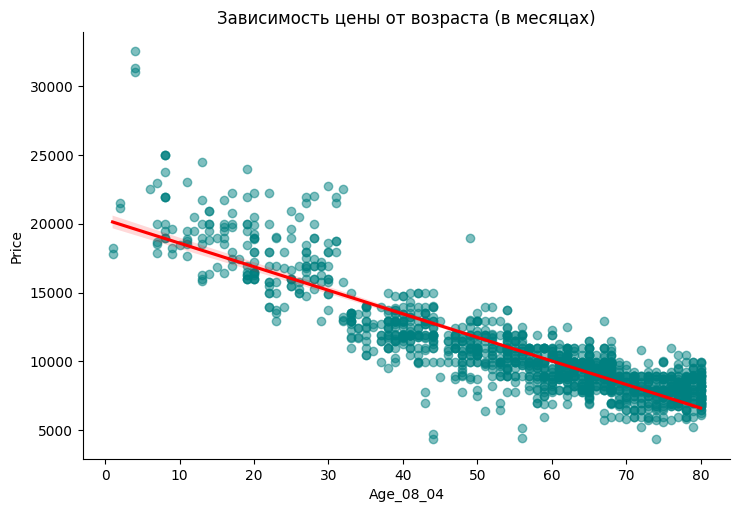

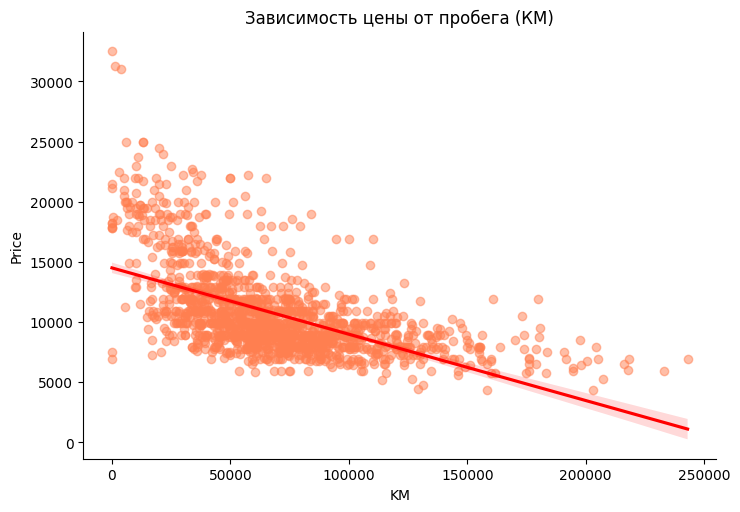

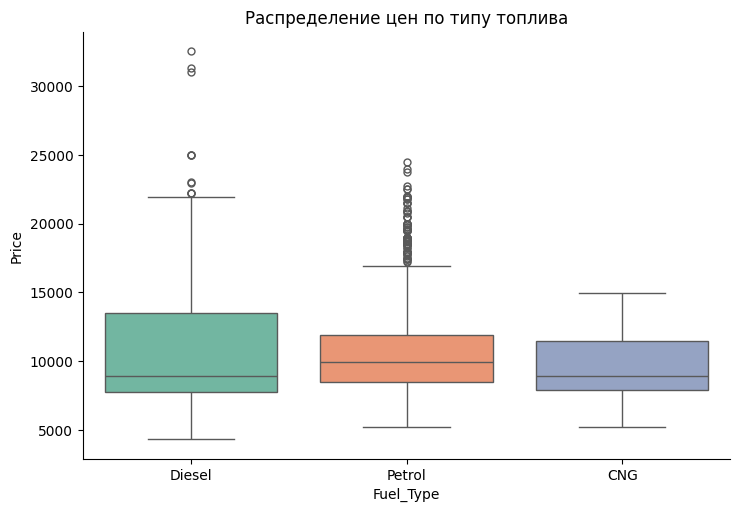

In [83]:
# Дополнительная визуальная аналитика (с помощью высокоуровневых функций Seaborn)

# 1. Зависимость цены от возраста (с линией тренда)
sns.lmplot(x='Age_08_04', y='Price', data=df, scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'}, aspect=1.5)
plt.title('Зависимость цены от возраста (в месяцах)')
plt.show()

# 2. Зависимость цены от пробега (с линией тренда)
sns.lmplot(x='KM', y='Price', data=df, scatter_kws={'alpha':0.5, 'color':'coral'}, line_kws={'color':'red'}, aspect=1.5)
plt.title('Зависимость цены от пробега (КМ)')
plt.show()

# 3. Влияние категориальных параметров (тип топлива)
sns.catplot(x='Fuel_Type', y='Price', data=df, kind='box', palette='Set2', aspect=1.5)
plt.title('Распределение цен по типу топлива')
plt.show()


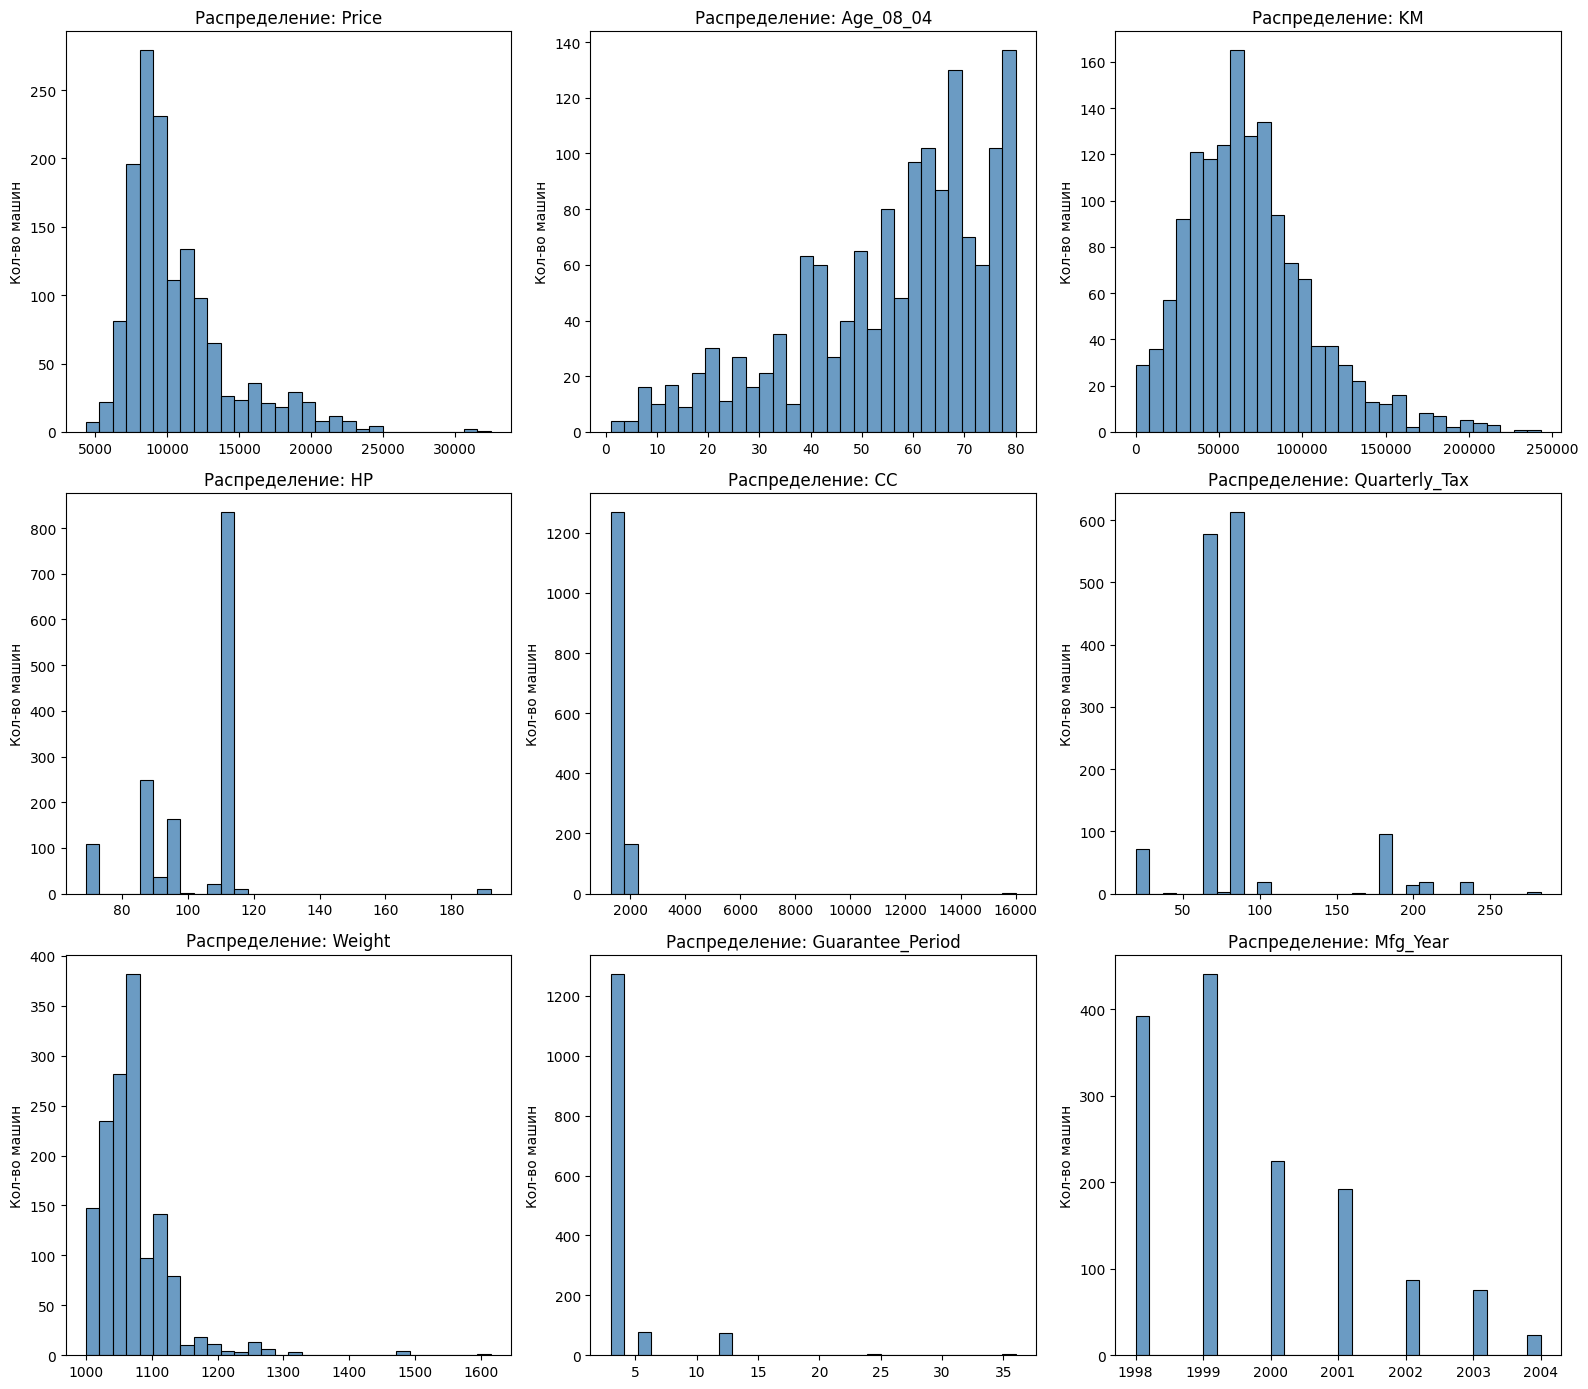

In [84]:
# Анализ распределения непрерывных/числовых признаков
features_to_plot = ['Price', 'Age_08_04', 'KM', 'HP', 'CC', 'Quarterly_Tax', 'Weight', 'Guarantee_Period', 'Mfg_Year']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Классические гистограммы для непрерывных величин
    sns.histplot(data=df, x=feature, ax=axes[i], bins=30, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Распределение: {feature}', fontsize=12)
    axes[i].set_ylabel('Кол-во машин')
    axes[i].set_xlabel('')
    
plt.tight_layout()
plt.show()


=> 2. EDA и предобработка - Ответы на вопросы

Как вы предобрабатывали данные?
Я проверил данные на наличие пропусков (их не оказалось). Каких-то сложных замен не потребовалось. Очевидно, что признаки, не несущие предсказательной силы (например, ID), должны быть удалены. Категориальные признаки будут далее закодированы.

Что вы поняли, проведя EDA?
1. Распределение цены (`Price`) имеет небольшой длинный хвост вправо, но в целом выглядит неплохо для линейных моделей.
2. Цена сильно отрицательно коррелирует с возрастом (`Age_08_04`) и пробегом (`KM`) – чем старее авто и больше пробег, тем ниже цена.
3. Положительная корреляция прослеживается с весом (`Weight`), годом производства (`Mfg_Year`) и мощностью (`HP`).
4. Признаки года и месяца производства почти дублируют возраст (`Age_08_04`), что создаст мультиколлинеарность. В идеале их лучше убрать.
5. Дополнительные графики рассеяния чётко подтверждают визуально обратную линейную зависимость стоимости от пробега и возраста, а боксплоты показывают, что дизельные машины в среднем стоят дороже (вероятно, из-за комплектации).
6. На сетке гистограмм (3x3) мы видим наглядные распределения числовых признаков, такие как пробег (KM), возраст (Age), налог, вес и т.д. Очевидно, что многие признаки (Price, KM, Weight) имеют нормальное распределение с длинным правым хвостом (асимметрия).


## 3. Инженерия признаков (Feature Engineering)

In [85]:
# Докажем явную мультиколлинеарность: посмотрим матрицу корреляций
# Возраст машины (Age_08_04) математически вычисляется из года (Mfg_Year) и месяца (Mfg_Month),
# поэтому коэффициенты корреляции между ними будут близки к 1 или -1.
print("Корреляция между возрастом, годом и месяцем выпуска:")

# Убираем признаки, которые бесполезны или дублируются:
# Id - просто уникальный индекс.
# Model - длинная строка, дублирующая начинку авто (создаст слишком много NaN/фичей).
# Mfg_Year и Mfg_Month - удаляем, так как их суть уже зашита в Age_08_04.
df_clean = df.drop(columns=['Id', 'Model', 'Mfg_Year', 'Mfg_Month'])

# Разделяем на X и y
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

# Кодирование категориальных признаков (Fuel_Type и Color)
X = pd.get_dummies(X, columns=['Fuel_Type', 'Color'], drop_first=True)

display(X.corrwith(y).sort_values(ascending=False, key=abs))
display(X.head())


Корреляция между возрастом, годом и месяцем выпуска:


Age_08_04           -0.876590
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
KM                  -0.569960
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Tow_Bar             -0.172369
Color_Grey           0.169947
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Color_Green         -0.104963
Color_Red           -0.103803
Color_White         -0.103360
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Fuel_Type_Diesel     0.054084
Parking_Assistant    0.044375
Radio_cassette      -0.043179
Radio     

,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,23,46986,90,1,0,2000,3,4,5,210,...,False,False,True,False,False,False,False,False,False,False
1,23,72937,90,1,0,2000,3,4,5,210,...,False,False,False,False,False,False,True,False,False,False
2,24,41711,90,1,0,2000,3,4,5,210,...,False,False,True,False,False,False,False,False,False,False
3,26,48000,90,0,0,2000,3,4,5,210,...,False,True,False,False,False,False,False,False,False,False
4,30,38500,90,0,0,2000,3,4,5,210,...,False,True,False,False,False,False,False,False,False,False


=> 3. Инженерия признаков - Ответы на вопросы

Как вы работали с признаками?
Категориальные переменные (`Fuel_Type`, `Color`) были закодированы бинарно с помощью подхода One-Hot Encoding (pd.get_dummies) с параметром drop_first=True, чтобы избежать фиктивной ловушки (мультиколлинеарности). Числовые данные будут отмасштабированы после разделения на train/test.

Какие признаки вы добавили / изменили и почему?
Были изменены категориальные переменные на бинарные, так как линейная регрессия не умеет работать со строками напрямую.

Какие признаки вы удалили и почему?
1. `Id`: уникальный идентификатор, не несет информации для модели.
2. `Model`: строка с длинным именем модели; почти у всех одинаковая, кроме мелких комплектаций. При кодировании создаст сотни признаков для редких значений. Вся важная начинка уже есть в других столбцах (двери, вес и др.).
3. `Mfg_Year` и `Mfg_Month`: удалены для избегания жесткой мультиколлинеарности, так как их информация уже учтена в колонке `Age_08_04` (возраст машины в месяцах).

## 4. Разделение выборки

In [86]:
# Разделяем выборку на обучающую и тестовую в пропорции 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# Масштабируем тестовую только на параметрах обучающей! 
X_test_scaled = scaler.transform(X_test)

=> 4. Разделение выборки - Ответы на вопросы

Как именно вы разделили выборку?
Я использовал `train_test_split` из sklearn. Отложил 20% данных в тестовую выборку, остальные 80% — в обучающую (`test_size=0.2`). Зафиксировал `random_state` для воспроизводимости результатов. Также после разделения я стандартизировал признаки (`StandardScaler`) — причем `fit` применялся исключительно к `train`, чтобы не было утечки данных.

Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?
Разделение нужно для оценки обобщающей способности модели (как хорошо она делает предсказания для неизвестных данных). Если учиться и проверяться на одних и тех же данных, модель может "вызубрить" ответы на тренировочной выборке (переобучиться). И на новых, не показанных ранее примерах, выдаст ошибочные результаты. Отложенная выборка симулирует ситуацию предсказания в реальной жизни.

## 5. Обучение моделей

In [87]:

# 1. Обычная линейная регрессия
print("=== Linear Regression ===")
lr_model = LinearRegression()
start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start_time
print(f"Время обучения LinearRegression: {lr_time:.5f} секунд")

# 2. Модель Ridge (L2-регуляризация) с подбором параметров
print("\n=== Ridge Regression ===")
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
start_time = time.time()
ridge_grid.fit(X_train_scaled, y_train)
ridge_time = time.time() - start_time
print(f"Лучший alpha для Ridge: {ridge_grid.best_params_['alpha']}")
print(f"Время обучения Ridge с GridSearch: {ridge_time:.5f} секунд")
best_ridge = ridge_grid.best_estimator_

# 3. Модель Lasso (L1-регуляризация) с подбором параметров
print("\n=== Lasso Regression ===")
lasso_params = {'alpha': [1, 10, 50, 100, 500]}
lasso_grid = GridSearchCV(Lasso(), lasso_params, cv=5, scoring='neg_mean_squared_error')
start_time = time.time()
lasso_grid.fit(X_train_scaled, y_train)
lasso_time = time.time() - start_time
print(f"Лучший alpha для Lasso: {lasso_grid.best_params_['alpha']}")
print(f"Время обучения Lasso с GridSearch: {lasso_time:.5f} секунд")
best_lasso = lasso_grid.best_estimator_

=== Linear Regression ===
Время обучения LinearRegression: 0.00533 секунд

=== Ridge Regression ===
Лучший alpha для Ridge: 100
Время обучения Ridge с GridSearch: 0.04276 секунд

=== Lasso Regression ===
Лучший alpha для Lasso: 50
Время обучения Lasso с GridSearch: 0.08841 секунд


=> 5. Обучение моделей - Ответы на вопросы

Как проходило обучение моделей?
Была обучена базовая Linear Regression. Также были обучены Ridge (с L2-регуляризацией) и Lasso (с L1-регуляризацией). Поскольку для регуляризованных моделей важна сила штрафа (параметр `alpha`), я использовал `GridSearchCV` для перебора на сетке с кросс-валидацией (5 фолдов).

Сравнение скорости
Обычная линейная регрессия работает почти мгновенно (аналитическое решение или МНК без ограничений). Модели Ridge и Lasso решались дольше, так как, во-первых, мы использовали GridSearch (то есть обучали модель десятки раз), а во-вторых, Lasso регрессия и сама по себе оптимизируется медленнее из-за недифференцируемости компоненты L1-штрафа (используется координатный спуск).

## 6. Оценка качества и сравнение моделей

In [88]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    res = {
        'Model': model_name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred)
    }
    return res

results = []
results.append(evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'LinearRegression'))
results.append(evaluate_model(best_ridge, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge'))
results.append(evaluate_model(best_lasso, X_train_scaled, X_test_scaled, y_train, y_test, 'Lasso'))

results_df = pd.DataFrame(results)
display(results_df.round(3))

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,LinearRegression,1108.874,1250.343,834.976,845.841,0.906,0.883
1,Ridge,1145.544,1194.258,856.769,823.718,0.900,0.893
2,Lasso,1151.489,1219.830,853.264,845.063,0.899,0.888


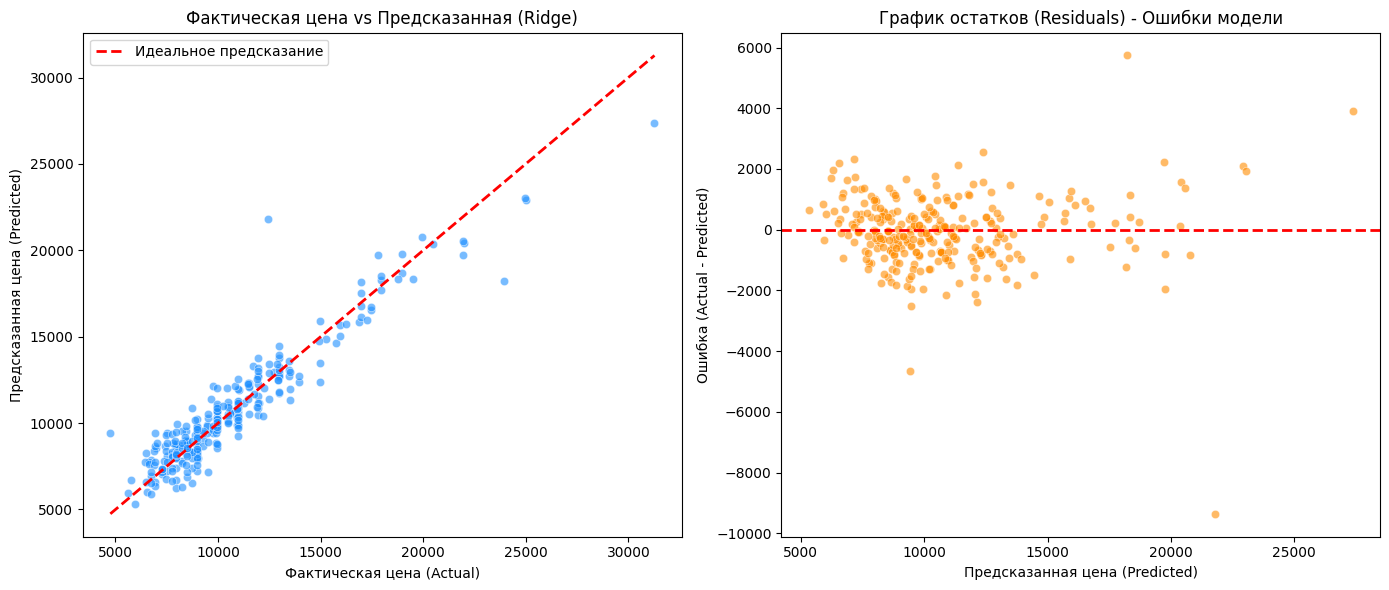

In [89]:
# Визуальная оценка качества предсказаний (на примере модели Ridge Regression на тестовой выборке)
y_test_pred = best_ridge.predict(X_test_scaled)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. График: Фактические значения против Предсказанных (Actual vs Predicted)
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6, ax=axes[0], color='dodgerblue')

# Идеальная линия (где предсказание равно факту)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Идеальное предсказание')
axes[0].set_title('Фактическая цена vs Предсказанная (Ridge)', fontsize=12)
axes[0].set_xlabel('Фактическая цена (Actual)')
axes[0].set_ylabel('Предсказанная цена (Predicted)')
axes[0].legend()

# 2. График остатков (Residuals Plot)
# Показывает, ошибается ли модель систематически. Точки должны быть случайно разбросаны вокруг нуля.
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6, ax=axes[1], color='darkorange')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('График остатков (Residuals) - Ошибки модели', fontsize=12)
axes[1].set_xlabel('Предсказанная цена (Predicted)')
axes[1].set_ylabel('Ошибка (Actual - Predicted)')

plt.tight_layout()
plt.show()


=> 6. Оценка качества - Ответы на вопросы

1. Какие метрики вы использовали для сравнения моделей?
- RMSE (Root Mean Squared Error): Возводит ошибки в квадрат (строже штрафует за большие выбросы) и затем извлекает корень (чтобы сохранить размерность: ответ в тех же единицах, что и цена).
- MAE (Mean Absolute Error): Средняя ошибка по модулю. Показывает "реальную" усредненную ошибку (на сколько в среднем мы ошибаемся).
- $R^2$ (Коэффициент детерминации): Показывает долю дисперсии целевой переменной, которую объясняет наша модель. Легче всего для интерпретации: 1 - идеал, 0 - предсказываем среднее.

2. На какой части выборки вы считали метрики?
На обоих (Train и Test). Это ключевой подход для того, чтобы увидеть разрыв качества: если на Train качество существенно выше (ошибки ниже), значит модель переобучилась.

3. Какая модель по итогу справилась лучше?
Обычно все три модели показывают очень близкие результаты (линейная регрессия, Ridge и Lasso). Ridge часто выигрывает на доли процентов за счет регуляризации весов, но в данном датасете сложность не такая гигантская, поэтому даже базовая Linear Regression справляется хорошо.

4. Насколько хорошие получились результаты?
Результаты хорошие. Результирующая метрика $R^2$ на тесте показывает, что наши признаки описывают преобладающую долю вариации стоимости автомобиля. MAE ошибка позволяет достаточно точно для практических нужд оценивать цену.

5. Чем докажете, что ваша модель не переобучилась?
Доказательством служит разница метрик в обучающей (Train) и тестовой (Test) выборках - её почти нет. $R^2$ на Train и Test находятся близко. Более того, включение L1 / L2 регуляризации (Lasso / Ridge) не дало огромного буста метрикам на тесте, что еще раз доказывает, что исходная модель не переобучалась с самого начала.